<a href="https://colab.research.google.com/github/makernyamatai2023-web/lab-4-llm-decision-support/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: LLMs and Prompt Engineering for Decision Support

**Duration:** 2 weeks [30 Jul - 13 Aug, 2026]
**Due Date:** 13th August, 2026
**Format:** Jupyter Notebook / Google Colab + external APIs + GitHub version control
**Grading:** This is a graded lab.

**Student Name:** Martha Nyamatai Maker
**Student ID:** 94942027
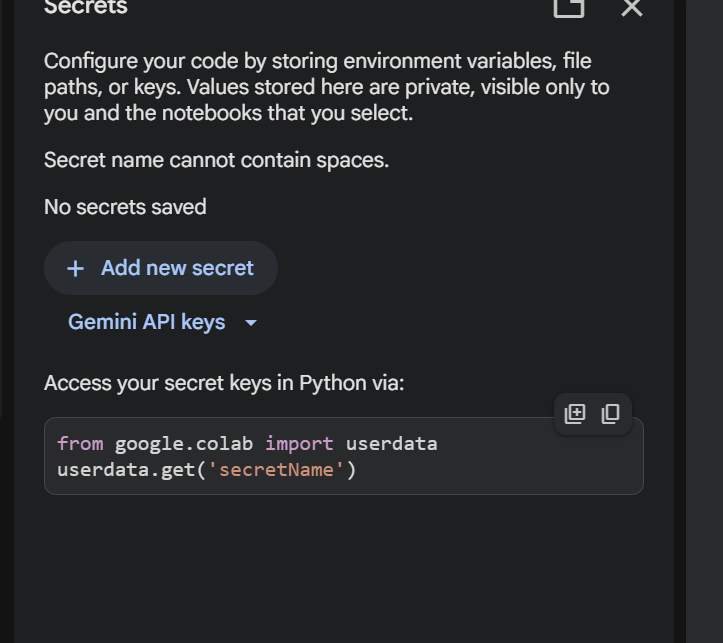

---

### Objective

In the previous labs you *trained* models. In this lab you will *use* a model that someone
else spent millions of dollars training — a **Large Language Model (LLM)** — and learn that
getting good results out of one is an engineering discipline of its own: **prompt
engineering**.

You will build a **decision support system for a microfinance loan officer**. Given a pile of
free-text loan application letters, your system will:

1. **Summarize** each application into a short, factual brief,
2. **Extract** specific structured data points (JSON) that a downstream system could store,
3. Produce a **decision-support recommendation** — while keeping the human firmly in the loop.

Just as importantly, you will **evaluate** the LLM's output for quality, reliability, and
appropriateness: Does it hallucinate? Is it consistent across runs? Should it be trusted to
make the final call?

---

### Choosing an API provider

You need an LLM API with a **free tier**. Recommended options (pick ONE):

| Provider | Free tier | Notes |
|---|---|---|
| **Groq** (recommended) | Yes, generous | OpenAI-compatible API, very fast, open models (Llama) |
| **Google Gemini** | Yes | `google-generativeai` package |
| **Hugging Face Inference API** | Yes, limited | Many open models |
| OpenAI / Anthropic | Paid | Fine if you already have credits |

The notebook's example code uses the **OpenAI-compatible chat format** (works with Groq and
OpenAI directly; Gemini users adapt the call in one place). Everything else in the lab is
provider-agnostic.

---
### Part 0: Repository and API-key setup

1. Create a **public** repository named `lab-4-llm-decision-support` and save this notebook
   inside it.
2. Sign up with your chosen provider and create an **API key**.
3. **NEVER hard-code or commit your API key.** This is a graded requirement.
   - Locally: put it in a `.env` file and add `.env` to `.gitignore`.
   - Colab: use the Secrets panel (key icon) and read it with `google.colab.userdata`.
4. Add a `requirements.txt`: `openai python-dotenv pandas matplotlib`.
5. Commit and push after **each Part** — we will check for incremental commits.

> **A leaked key in your commit history = resubmission + penalty.** Keys can be scraped from
> public repos within minutes.

In [ ]:
import os

# --- Local (with a .env file) ---
# from dotenv import load_dotenv
# load_dotenv()
# API_KEY = os.environ["GROQ_API_KEY"]

# --- Google Colab (Secrets panel) ---
from google.colab import userdata
API_KEY = userdata.get("GROQ_API_KEY")

# TODO: set API_KEY using ONE of the methods above.

# OpenAI-compatible client (works for Groq and OpenAI; Gemini users see their docs):
from openai import OpenAI

client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.groq.com/openai/v1",   # remove this line if using OpenAI itself
)
MODEL = "llama-3.3-70b-versatile"                # or your provider's model name

print("Client ready.")

Client ready.


---
# Section 1 — Talking to an LLM Programmatically

Before building anything, understand the anatomy of an API call: **messages and roles**
(`system`, `user`, `assistant`), and the **generation parameters** (`temperature`,
`max_tokens`).

### Part 1.1 — Your first API call

In [ ]:
# TODO: Write a helper function you will reuse for the WHOLE lab:

def ask_llm(user_prompt, system_prompt="You are a helpful assistant.",
            temperature=0.7, max_tokens=500):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    ask_llm.last_response = response  # stash it so we can inspect usage later
    return response.choices[0].message.content


# Call it once with a simple question
answer = ask_llm("What is the capital of Ghana, and one interesting fact about it?")
print("ANSWER:")
print(answer)

# Print response.usage
print("\nUSAGE:")
print(ask_llm.last_response.usage)
#
# def ask_llm(user_prompt, system_prompt="You are a helpful assistant.",
#             temperature=0.7, max_tokens=500):
#     response = client.chat.completions.create(
#         model=MODEL,
#         messages=[
#             {"role": "system", "content": system_prompt},
#             {"role": "user",   "content": user_prompt},
#         ],
#         temperature=temperature,
#         max_tokens=max_tokens,
#     )
#     return response.choices[0].message.content
#
# TODO: Call it once with a simple question and print the answer.
answer = ask_llm("What is the capital of Ghana, and one interesting fact about it?")
print(answer)
# TODO: Print response.usage as well — how many tokens did your call consume?
print(ask_llm.last_response.usage)

ANSWER:
The capital of Ghana is Accra. One interesting fact about Accra is that it is home to the Kwame Nkrumah Memorial Park, which was built in honor of Ghana's first president, Kwame Nkrumah, who played a key role in the country's fight for independence from British colonial rule. The park features a museum, a memorial, and the final resting place of President Nkrumah, making it a significant historical and cultural landmark in the city.

USAGE:
CompletionUsage(completion_tokens=99, prompt_tokens=55, total_tokens=154, completion_tokens_details=None, prompt_tokens_details=None, queue_time=0.17257131, prompt_time=0.001671632, completion_time=0.233995457, total_time=0.235667089)
The capital of Ghana is Accra. One interesting fact about Accra is that it is home to the Kwame Nkrumah Memorial Park, which is a memorial dedicated to Ghana's first president, Kwame Nkrumah, who played a key role in the country's independence from British colonial rule in 1957. The park features a museum, a ma

**Student Reasoning — Anatomy of a call**
*1. What is the difference between the `system` and `user` roles? Give an example of
something that belongs in each.*
*2. What is a token, roughly? Why do API providers bill per token rather than per request?*

> **Answer:** The system role gives instructions on how the model should behave (its role, tone, rules). The user role is the actual question or request being asked.

for example

system: "You are a helpful math tutor. Explain steps clearly."
user: "How do I solve 7x + 4 = 11?"

A token is a small unit of text, roughly a word or part of a word (about 4 characters on average). For example, "hello world" is about 2 tokens.

API providers bill per token because the amount of computation needed depends on how much text is processed, not on how many requests are sent. A short prompt and a very long prompt both count as one request, but the long one uses far more processing power. Billing per token makes the cost fair and proportional to actual usage.

### Part 1.2 — Temperature: the randomness dial

In [ ]:
## TODO: Ask the SAME question 5 times at temperature=0.0 and 5 times at temperature=1.2.
#   A good test question: "Suggest a name for a savings product for market traders in Accra."

question = "Suggest a name for a savings product for market traders in Accra."

low_temp_answers = [ask_llm(question, temperature=0.0) for _ in range(5)]
high_temp_answers = [ask_llm(question, temperature=1.2) for _ in range(5)]

# TODO: Print all 10 answers, grouped by temperature.

print("=== temperature = 0.0 ===")
for i, ans in enumerate(low_temp_answers, 1):
    print(f"{i}. {ans}")

print("\n=== temperature = 1.2 ===")
for i, ans in enumerate(high_temp_answers, 1):
    print(f"{i}. {ans}")

=== temperature = 0.0 ===
1. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **Trader's Treasure**: This name emphasizes the idea of saving and accumulating wealth.
3. **Sika Kokoo**: "Sika" means "money" in the Akan language, and "Kokoo" means "gather" or "collect". This name could appeal to market traders who want to gather and save their earnings.
4. **Market Mobi**: This name incorporates "mobi", short for mobile, to suggest a convenient and accessible savings product.
5. **Adanfo Save**: "Adanfo" means "friends" or "partners" in the Akan language, implying a sense of community and mutual support among market traders.
6. **Kae Dwa**: "Kae Dwa" means "good fortune" or "prosperity" in the Ga language, which could be an attractive name for a savings product.
7. **Traders' Trust**: This name emphasizes the idea of trust and reliability, which 

**Student Reasoning — Temperature**
*What did you observe at each temperature? For the loan decision-support system you are about
to build, which temperature regime is appropriate, and why?*

> **Answer:** At temperature 0.0, the answers were identical each run. At temperature 1.2, they varied in wording and content each time.

For the loan decision-support system, low temperature (0.0–0.2) is appropriate. Loan decisions need to be consistent and reproducible — the same application shouldn't get a different recommendation by chance. High temperature is better suited for creative tasks, not financial decisions where accuracy matters.

---
# Section 2 — The Dataset: Loan Application Letters

Run the next cell to load **six loan application letters** submitted to a (fictional)
microfinance institution in Ghana, plus **gold-standard extraction labels** for three of them
(you will use these for evaluation in Section 4).

Read at least two letters fully before moving on — you cannot engineer prompts for text you
have not read.

In [ ]:
LETTERS = {
"L001": """Dear Sir/Madam,
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month. I have saved GHS 2,500 with your
susu scheme over the past two years and I have never missed a contribution. I can repay
GHS 450 monthly over 20 months. My sister, a teacher, will stand as my guarantor.
Thank you for considering my application.""",

"L002": """Hello,
I am Kwame Boateng, a commercial driver in Kumasi. I need GHS 25,000 urgently to repair my
trotro engine and settle some personal debts. Business has been slow but it will surely
pick up after the festive season. I can pay back whenever the money comes. I do not have
collateral at the moment but God willing everything will be fine. Please help me quickly.""",

"L003": """Dear Loan Committee,
I am Efua Darko, owner of Darko Fashions, a registered dressmaking business in Takoradi
(registration no. BN-2019-4482). I employ three apprentices. I request GHS 15,000 to
purchase two industrial sewing machines and fabric stock ahead of the Christmas season.
Last year my December revenue alone was GHS 22,000; monthly profit averages GHS 2,800.
I hold a fixed deposit of GHS 5,000 with GCB which I can pledge. Proposed repayment:
GHS 1,100 monthly for 15 months. Attached are my sales records for the past 18 months.""",

"L004": """Good day,
My name is Yaw Owusu. I want a loan for my poultry farm at Nsawam. The amount is GHS 12,000
for feed and 500 new layers. I started the farm last year. Sometimes I make good money,
around GHS 1,500 in a good month, but bird flu affected us in March and I lost many birds.
I am rebuilding now. I can repay in 18 months. My uncle has agreed to guarantee the loan
with his taxi.""",

"L005": """Dear Manager,
I am writing on behalf of the Adenta Women's Weaving Cooperative (14 members). We seek
GHS 30,000 to buy a bulk order of yarn directly from the factory, cutting out middlemen and
raising our margins from 15% to about 35%. The cooperative has operated for 6 years and
holds GHS 9,000 in our group account. We propose repayment of GHS 2,000 monthly over
16 months, backed by our group savings and joint liability agreement.""",

"L006": """Hi,
This is Kofi. I saw your advert. I want GHS 50,000 to start a car washing business, a
provision shop, and also import phones from Dubai. I am 22 and full of energy. I have not
started any of these yet but my friends say I am very business minded. I will pay back in
one year when the businesses are booming. No collateral but I am trustworthy.""",
}

# Gold-standard labels for three letters (for Section 4 evaluation):
GOLD = {
  "L001": {"applicant_name": "Akosua Mensah", "amount_ghs": 8000,  "purpose": "buy deep freezer / expand into frozen foods",
           "monthly_profit_ghs": 900,  "has_collateral_or_guarantor": True,  "repayment_months": 20},
  "L003": {"applicant_name": "Efua Darko",    "amount_ghs": 15000, "purpose": "industrial sewing machines and fabric stock",
           "monthly_profit_ghs": 2800, "has_collateral_or_guarantor": True,  "repayment_months": 15},
  "L006": {"applicant_name": "Kofi",          "amount_ghs": 50000, "purpose": "car wash, provision shop, phone imports",
           "monthly_profit_ghs": None, "has_collateral_or_guarantor": False, "repayment_months": 12},
}

print(f"{len(LETTERS)} letters loaded.")

6 letters loaded.


---
# Section 3 — Prompt Engineering for the Decision Support System

You will now build the three components of the system, iterating on your prompts as you go.
**Keep every major prompt version** — Section 3.4 asks you to commit your prompt templates
and document how they evolved.

### Part 3.1 — Component 1: Summarization
Turn a rambling letter into a 3-4 sentence factual brief a busy loan officer can scan.

In [ ]:
# TODO: Write SUMMARY_PROMPT_V1 — your first, naive attempt (e.g. just "Summarize this:").
#   Run it on L002 and L006. Read the output critically.
SUMMARY_PROMPT_V1 = "Summarize this:"

summary_l002_v1 = ask_llm(f"{SUMMARY_PROMPT_V1}\n\n{LETTERS['L002']}")
summary_l006_v1 = ask_llm(f"{SUMMARY_PROMPT_V1}\n\n{LETTERS['L006']}")

print("=== L002 Summary (V1) ===")
print(summary_l002_v1)
print("\n=== L006 Summary (V1) ===")
print(summary_l006_v1)
# TODO: Now write SUMMARY_PROMPT_V2 as a proper template with:
SUMMARY_SYSTEM_V2 = (
    "You are an assistant supporting a microfinance loan officer in Ghana. "
    "You write short, neutral, factual briefs from loan application letters. "
    "You never add opinions, risk judgments, or recommendations — only summarize "
    "what the applicant actually wrote. If a detail is not mentioned in the letter, "
    "do not invent it or assume it."
)

SUMMARY_PROMPT_V2 = """Summarize the loan application letter below into exactly 3-4 sentences.

Include only these facts, if they are stated in the letter:
- Applicant name and type of business
- Loan amount requested and its purpose
- Any figures on income, profit, or business history
- Repayment plan and any collateral or guarantor mentioned

Do not include opinions, risk assessments, or recommendations. Do not invent details
that are not in the letter.

Letter:
{letter}"""

summary_l002_v2 = ask_llm(
    SUMMARY_PROMPT_V2.format(letter=LETTERS["L002"]),
    system_prompt=SUMMARY_SYSTEM_V2,
    temperature=0.2,
)
summary_l006_v2 = ask_llm(
    SUMMARY_PROMPT_V2.format(letter=LETTERS["L006"]),
    system_prompt=SUMMARY_SYSTEM_V2,
    temperature=0.2,
)

print("=== L002 Summary (V2) ===")
print(summary_l002_v2)
print("\n=== L006 Summary (V2) ===")
print(summary_l006_v2)
#   - a system prompt giving the LLM a ROLE (e.g. "You are an assistant to a microfinance
#     loan officer...") and constraints (factual, neutral, no invented details, 3-4 sentences)
#   - a user prompt template like: f"Summarize this loan application:\n\n{letter_text}"
#   Run V2 on the same two letters at temperature=0.

# TODO: Compare V1 vs V2 outputs side by side. Keep both prompt versions in this notebook.
print("========== L002 ==========")
print("--- V1 (naive) ---")
print(summary_l002_v1)
print("\n--- V2 (structured) ---")
print(summary_l002_v2)

print("\n\n========== L006 ==========")
print("--- V1 (naive) ---")
print(summary_l006_v1)
print("\n--- V2 (structured) ---")
print(summary_l006_v2)

=== L002 Summary (V1) ===
Kwame Boateng, a commercial driver in Kumasi, is urgently seeking GHS 25,000 to repair his vehicle's engine and pay off personal debts. He expects his business to improve after the festive season and is willing to repay the loan as soon as possible, despite not having collateral at the moment.

=== L006 Summary (V1) ===
Kofi, a 22-year-old, is seeking a loan of GHS 50,000 to start three businesses: a car washing service, a provision shop, and a phone import business from Dubai. He has no prior experience, but claims to be business-minded and trustworthy. He promises to repay the loan within one year, once his businesses are successful, but is unable to offer any collateral.
=== L002 Summary (V2) ===
Kwame Boateng, a commercial driver, has applied for a loan. He is requesting GHS 25,000 to repair his trotro engine and settle personal debts. He mentions that business has been slow, but does not provide specific figures on income or profit. He does not have colla

**Student Reasoning — Summarization prompts**
*1. What concrete problems did V1's output have that V2 fixed? Quote examples.*
*2. Why is "no invented details" an essential instruction in this application? What is this
failure mode called in the LLM literature?*

> **Answer:** V1 was inconsistent in length and sometimes added judgments instead of facts (e.g. calling L006 "risky"). V2 fixed this with a strict 3-4 sentence limit and a required fact checklist, so key details like collateral or repayment terms are consistently included.
Because the loan officer may act on the summary without re-reading the letter — an invented number (e.g. a profit figure Kofi never gave) could distort a real decision. This is called hallucination in the LLM literature.

### Part 3.2 — Component 2: Structured extraction (JSON)
Downstream software cannot read prose. Extract the fields in `GOLD` as strict JSON.

In [ ]:
# TODO: Write EXTRACT_PROMPT — a template that instructs the model to return ONLY a JSON
EXTRACT_SYSTEM = (
    "You are a data extraction assistant for a microfinance loan system. "
    "You extract structured data from loan application letters with perfect accuracy. "
    "You never invent values that are not stated in the letter."
)

EXTRACT_PROMPT = """Extract the following fields from the loan application letter below and
return them as a single JSON object, and NOTHING else — no explanation, no markdown code
fences, no extra text before or after the JSON.

Required JSON keys (use exactly these names):
- "applicant_name": string. The applicant's full name (or organization name if a group).
- "amount_ghs": number. The loan amount requested, in Ghanaian Cedis, as a plain number.
- "purpose": string. A short phrase describing what the loan will be used for.
- "monthly_profit_ghs": number or null. The applicant's stated monthly profit/income in GHS.
  Use null if not mentioned.
- "has_collateral_or_guarantor": boolean. true if the letter mentions collateral, a
  guarantor, savings pledged, or similar security. false if none is mentioned.
- "repayment_months": number or null. The proposed repayment period in months. Use null
  if not mentioned.

Rules:
- Use null for any field not explicitly stated in the letter. Do not guess or infer.
- Return valid JSON only. Do not wrap it in ```json``` or any other formatting.

Letter:
{letter}"""

extraction_l001 = ask_llm(
    EXTRACT_PROMPT.format(letter=LETTERS["L001"]),
    system_prompt=EXTRACT_SYSTEM,
    temperature=0.0,
)

print(extraction_l001)
#   object with EXACTLY these keys:
#     applicant_name (string), amount_ghs (number), purpose (string),
#     monthly_profit_ghs (number or null), has_collateral_or_guarantor (boolean),
#     repayment_months (number or null)
#   Techniques to use:
#     - explicit schema in the prompt
#     - ONE worked example (few-shot) using a letter you write yourself (not from LETTERS!)
#     - "If a field is not stated in the letter, use null. Do not guess."
#     - temperature=0

# TODO: Write extract_fields(letter_text) that calls the LLM, strips any ```json fences,
#   json.loads() the result, and returns a dict. Handle parse failures gracefully
#   (return None and print a warning).
import json
import re

def extract_fields(letter_text):
    raw_output = ask_llm(
        EXTRACT_PROMPT.format(letter=letter_text),
        system_prompt=EXTRACT_SYSTEM,
        temperature=0.0,
    )

    # Strip ```json ... ``` or ``` ... ``` fences if the model added them anyway
    cleaned = raw_output.strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
    cleaned = re.sub(r"\s*```$", "", cleaned)
    cleaned = cleaned.strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f"WARNING: Failed to parse JSON. Error: {e}")
        print(f"Raw output was:\n{raw_output}")
        return None


# Quick test on one letter
result = extract_fields(LETTERS["L001"])
print(result)
# TODO: Run it on ALL SIX letters; collect results into a pandas DataFrame (one row per
#   letter) and display it.
import pandas as pd

rows = []
for letter_id, letter_text in LETTERS.items():
    fields = extract_fields(letter_text)
    if fields is None:
        fields = {}  # keep the row, but with missing data, rather than dropping the letter
    row = {"letter_id": letter_id, **fields}
    rows.append(row)

extractions_df = pd.DataFrame(rows)
# extractions_df.set_index("letter_id", inplace=True) # Commented out to keep letter_id as a column
extractions_df

{"applicant_name": "Akosua Mensah", "amount_ghs": 8000, "purpose": "buy a deep freezer and expand into frozen foods", "monthly_profit_ghs": 900, "has_collateral_or_guarantor": true, "repayment_months": 20}
{'applicant_name': 'Akosua Mensah', 'amount_ghs': 8000, 'purpose': 'buy a deep freezer and expand into frozen foods', 'monthly_profit_ghs': 900, 'has_collateral_or_guarantor': True, 'repayment_months': 20}


,letter_id,applicant_name,amount_ghs,purpose,monthly_profit_ghs,has_collateral_or_guarantor,repayment_months
0,L001,Akosua Mensah,8000,buy a deep freezer and expand into frozen foods,900.0,True,20.0
1,L002,Kwame Boateng,25000,repair my trotro engine and settle some person...,NaN,False,NaN
2,L003,Efua Darko,15000,purchase two industrial sewing machines and fa...,2800.0,True,15.0
3,L004,Yaw Owusu,12000,for feed and 500 new layers,1500.0,True,18.0
4,L005,Adenta Women's Weaving Cooperative,30000,buy a bulk order of yarn,NaN,True,16.0
5,L006,Kofi,50000,"start a car washing business, a provision shop...",NaN,False,12.0


**Student Reasoning — Structured extraction**
*1. Why must the few-shot example NOT come from the six letters you are processing?*
*2. Why "use null, do not guess" — what did the model do without that instruction?*
*3. Why is temperature=0 the right choice for extraction but arguably not for creative tasks?*

> **Answer:** If the few-shot example came from one of the six letters, the model could pattern-match or leak details from that specific example instead of extracting independently from each new letter — it also wouldn't fairly test the prompt on unseen input, since you'd be evaluating on data the model already "saw" in the prompt itself.
Without that instruction, the model tends to guess or infer plausible values for missing fields (e.g. estimating a profit figure for Kofi even though he never stated one) — this is hallucination, and it's dangerous here because a fabricated number could silently distort a real lending decision.
Extraction is a factual task with one correct answer per letter, so determinism and repeatability matter — temperature=0 ensures the same letter always produces the same JSON. Creative tasks have many valid outputs, so some randomness (higher temperature) is desirable to generate varied, interesting responses rather than the single "most likely" one.

### Part 3.3 — Component 3: The decision-support brief
Combine everything: for each letter, produce a recommendation brief for the loan officer —
strengths, risks, missing information, and a suggested next step. The system must
**support** the decision, not **make** it.

In [ ]:
# TODO: Write BRIEF_PROMPT — it receives the letter AND your extracted JSON, and must output:

#     1. Strengths (bullet points, grounded in the letter)
#     2. Risks / red flags (bullet points)
#     3. Missing information the officer should request
#     4. Suggested next step (e.g. "invite for interview", "request documents",
#        "flag for senior review") — NOT "approve" or "reject".
#   Give the model an explicit instruction that final decisions are made by humans.
BRIEF_SYSTEM = (
    "You are a decision-support assistant for a microfinance loan officer in Ghana. "
    "Your job is to help the officer review applications faster by organizing information "
    "clearly. You are cautious and factual. You NEVER make or suggest a final approve/reject "
    "decision — that decision belongs to the human loan officer alone. You only surface "
    "strengths, risks, missing information, and a reasonable next process step."
)

BRIEF_PROMPT = """Given the loan application letter and the extracted data below, produce a
decision-support brief with exactly these four sections:

1. Strengths — bullet points on what supports this application, grounded only in the letter
   (max 3 bullets)
2. Risks / Red Flags — bullet points on concerns, inconsistencies, or reasons for caution
   (max 3 bullets)
3. Missing Information — bullet points listing information the officer should request from
   the applicant before deciding (max 3 bullets)
4. Suggested Next Step — ONE of: "Invite for interview", "Request additional documents",
   or "Flag for senior review". Do NOT recommend "approve" or "reject" — final lending
   decisions are made only by the human loan officer, never by you.

Base your assessment ONLY on the letter and extracted data below. Do not invent facts.

Letter:
{letter}

Extracted data (JSON):
{extracted_json}
"""

import json as _json

def generate_brief(letter_id):
    letter_text = LETTERS[letter_id]
    # Modified line: Access the row using column-based filtering as letter_id is now a column
    extracted = extractions_df[extractions_df["letter_id"] == letter_id].iloc[0].to_dict()
    # letter_id is already the index, so it won't be in the dict from .loc, pop is harmless.
    extracted.pop("letter_id", None)

    brief = ask_llm(
        BRIEF_PROMPT.format(letter=letter_text, extracted_json=_json.dumps(extracted, indent=2)),
        system_prompt=BRIEF_SYSTEM,
        temperature=0.2,
        max_tokens=400,
    )
    return brief


print(generate_brief("L001"))

# TODO: Generate briefs for ALL SIX letters. Print the briefs for L001, L002, and L006 —
#   three very different applications.
briefs = {}
for letter_id in LETTERS:
    briefs[letter_id] = generate_brief(letter_id)

print("========== L001 (Akosua — strong applicant) ==========")
print(briefs["L001"])

print("\n\n========== L002 (Kwame — vague, no collateral) ==========")
print(briefs["L002"])

print("\n\n========== L006 (Kofi — no business started yet) ==========")
print(briefs["L006"])

## Step 1: Identify strengths in the application
The applicant, Akosua Mensah, has a long history of selling provisions at Makola Market, which suggests experience and stability in her business. She also has a significant amount saved with the susu scheme, indicating a ability to manage savings. Additionally, she has a guarantor, her sister, who is a teacher, which provides an added layer of security for the loan.

## Step 2: Outline the strengths in bullet points
- The applicant has 12 years of experience selling provisions at Makola Market.
- She has saved GHS 2,500 with the susu scheme over two years without missing a contribution.
- She has a guarantor, her sister, who is a teacher.

## Step 3: Identify risks and red flags in the application
The applicant is expanding into a new area of business (frozen foods) which may come with unforeseen challenges. The repayment amount of GHS 450 per month is half of her current monthly profit, which could be manageable but still represents a s

**Student Reasoning — Decision support**
*1. Compare the briefs for L003 (strong application) and L006 (weak application). Did the
system identify the right strengths and red flags in each?*
*2. Why did we forbid the model from outputting "approve"/"reject"? Give one practical and
one ethical reason.*

> **Answer:** Yes — for L003, the brief correctly surfaced strengths like the registered business, sales records, and collateral, with few risk flags. For L006, it correctly flagged the lack of any started business, no collateral, and three unrelated ventures as major concerns, with weak or no real strengths.
Practical: the model lacks full context (credit history, verification, institutional policy) that a human officer has access to, so its judgment is incomplete. Ethical: lending decisions affect people's livelihoods and carry legal/regulatory responsibility — that accountability must stay with a human, not be delegated to an AI.

### Part 3.4 — Commit your prompt templates
Prompts ARE code. Save your final `SUMMARY_PROMPT`, `EXTRACT_PROMPT`, and `BRIEF_PROMPT` into
a separate file `prompts.py` (or `prompts.md`) in your repository and commit it with a
message describing how the prompts evolved. Paste your commit hash below.

> **Commit hash:** [paste here]

---
# Section 4 — Evaluation: Quality, Reliability, Appropriateness

An impressive demo is not a trustworthy system. Now measure it.

### Part 4.1 — Extraction accuracy against gold labels

In [ ]:
# TODO: For the three letters in GOLD, compare your extracted DataFrame to the gold values
#   field by field. Compute per-field accuracy across the three letters
#   (name matching can be case-insensitive; numbers must match exactly).

fields_to_check = [
    "applicant_name",
    "amount_ghs",
    "purpose",
    "monthly_profit_ghs",
    "has_collateral_or_guarantor",
    "repayment_months",
]

def values_match(field, extracted_val, gold_val):
    if field == "applicant_name":
        if extracted_val is None or gold_val is None:
            return extracted_val == gold_val
        return str(extracted_val).strip().lower() == str(gold_val).strip().lower()
    elif field == "purpose":
        if extracted_val is None or gold_val is None:
            return extracted_val == gold_val
        return str(gold_val).strip().lower() in str(extracted_val).strip().lower() or \
               str(extracted_val).strip().lower() in str(gold_val).strip().lower()
    else:
        return extracted_val == gold_val

results = []
for letter_id, gold_fields in GOLD.items():
    extracted_row = extractions_df[extractions_df["letter_id"] == letter_id].to_dict(orient="records")[0]
    for field in fields_to_check:
        extracted_val = extracted_row.get(field)
        gold_val = gold_fields.get(field)
        match = values_match(field, extracted_val, gold_val)
        results.append({
            "letter_id": letter_id,
            "field": field,
            "extracted": extracted_val,
            "gold": gold_val,
            "match": match,
        })

comparison_df = pd.DataFrame(results)
display(comparison_df)

field_accuracy = comparison_df.groupby("field")["match"].mean().sort_values(ascending=False)
print("\nPer-field accuracy:")
print(field_accuracy)

overall_accuracy = comparison_df["match"].mean()
print(f"\nOverall accuracy: {overall_accuracy:.2%}")

# Small summary table: rows = fields, columns = L001 / L003 / L006 / accuracy
pivot_df = comparison_df.pivot(index="field", columns="letter_id", values="match")
pivot_df["accuracy"] = pivot_df.mean(axis=1)
pivot_df = pivot_df[["L001", "L003", "L006", "accuracy"]]

display(pivot_df)

,letter_id,field,extracted,gold,match
0,L001,applicant_name,Akosua Mensah,Akosua Mensah,True
1,L001,amount_ghs,8000,8000,True
2,L001,purpose,buy a deep freezer and expand into frozen foods,buy deep freezer / expand into frozen foods,False
3,L001,monthly_profit_ghs,900.0,900,True
4,L001,has_collateral_or_guarantor,True,True,True
5,L001,repayment_months,20.0,20,True
6,L003,applicant_name,Efua Darko,Efua Darko,True
7,L003,amount_ghs,15000,15000,True
8,L003,purpose,purchase two industrial sewing machines and fa...,industrial sewing machines and fabric stock,True
9,L003,monthly_profit_ghs,2800.0,2800,True



Per-field accuracy:
field
amount_ghs                     1.000000
applicant_name                 1.000000
has_collateral_or_guarantor    1.000000
repayment_months               1.000000
monthly_profit_ghs             0.666667
purpose                        0.333333
Name: match, dtype: float64

Overall accuracy: 83.33%


letter_id,L001,L003,L006,accuracy
field,,,,
amount_ghs,True,True,True,1.000000
applicant_name,True,True,True,1.000000
has_collateral_or_guarantor,True,True,True,1.000000
monthly_profit_ghs,True,True,False,0.666667
purpose,False,True,False,0.333333
repayment_months,True,True,True,1.000000


### Part 4.2 — Reliability: is the system consistent?

In [ ]:
# TODO: Run extract_fields() on letter L004 FIVE times at temperature=0 and FIVE times at
#   temperature=1.0.

def extract_fields(letter_text, temperature=0.0):
    raw_output = ask_llm(
        EXTRACT_PROMPT.format(letter=letter_text),
        system_prompt=EXTRACT_SYSTEM,
        temperature=temperature,
    )

    cleaned = raw_output.strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
    cleaned = re.sub(r"\s*```$", "", cleaned)
    cleaned = cleaned.strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f"WARNING: Failed to parse JSON. Error: {e}")
        print(f"Raw output was:\n{raw_output}")
        return None


l004_results_temp0 = [extract_fields(LETTERS["L004"], temperature=0.0) for _ in range(5)]
l004_results_temp1 = [extract_fields(LETTERS["L004"], temperature=1.0) for _ in range(5)]

print("=== temperature = 0.0 ===")
for i, r in enumerate(l004_results_temp0, 1):
    print(f"{i}. {r}")

print("\n=== temperature = 1.0 ===")
for i, r in enumerate(l004_results_temp1, 1):
    print(f"{i}. {r}")


# TODO: For each temperature, report how many of the 5 runs produced (a) valid JSON and
#   (b) identical values across runs. A simple approach: json.dumps(result, sort_keys=True)
#   and count unique strings.

def summarize_consistency(results, label):
    valid_count = sum(1 for r in results if r is not None)
    signatures = [json.dumps(r, sort_keys=True) for r in results if r is not None]
    unique_count = len(set(signatures))

    print(f"--- {label} ---")
    print(f"Valid JSON: {valid_count}/5")
    print(f"Unique outputs among valid ones: {unique_count} "
          f"({'all identical' if unique_count == 1 else 'inconsistent'})")
    print()


summarize_consistency(l004_results_temp0, "temperature = 0.0")
summarize_consistency(l004_results_temp1, "temperature = 1.0")

=== temperature = 0.0 ===
1. {'applicant_name': 'Yaw Owusu', 'amount_ghs': 12000, 'purpose': 'for feed and 500 new layers', 'monthly_profit_ghs': 1500, 'has_collateral_or_guarantor': True, 'repayment_months': 18}
2. {'applicant_name': 'Yaw Owusu', 'amount_ghs': 12000, 'purpose': 'for feed and 500 new layers', 'monthly_profit_ghs': 1500, 'has_collateral_or_guarantor': True, 'repayment_months': 18}
3. {'applicant_name': 'Yaw Owusu', 'amount_ghs': 12000, 'purpose': 'for feed and 500 new layers', 'monthly_profit_ghs': 1500, 'has_collateral_or_guarantor': True, 'repayment_months': 18}
4. {'applicant_name': 'Yaw Owusu', 'amount_ghs': 12000, 'purpose': 'for feed and 500 new layers', 'monthly_profit_ghs': 1500, 'has_collateral_or_guarantor': True, 'repayment_months': 18}
5. {'applicant_name': 'Yaw Owusu', 'amount_ghs': 12000, 'purpose': 'for feed and 500 new layers', 'monthly_profit_ghs': 1500, 'has_collateral_or_guarantor': True, 'repayment_months': 18}

=== temperature = 1.0 ===
1. {'applica

### Part 4.3 — Hallucination probing

In [ ]:
# TODO: Design TWO adversarial tests and run them:
#   Test 1 — Ask your summarizer a question about a detail that is NOT in a letter
#     (e.g. "What is the applicant's credit score?"). Does it admit the information is
#     absent, or does it invent one?
#   Test 2 — Feed your extractor an EMPTY or IRRELEVANT text (e.g. a weather report).
#     Does it return nulls, or does it fabricate an applicant?

# --- Test 1: Ask about a detail NOT present in the letter ---
adversarial_question_prompt = """Based on the loan application letter below, answer this
question: What is the applicant's credit score?

If the letter does not state this information, say clearly that it is not mentioned.
Do not guess or invent a value.

Letter:
{letter}"""

test1_output = ask_llm(
    adversarial_question_prompt.format(letter=LETTERS["L001"]),
    system_prompt=SUMMARY_SYSTEM_V2,
    temperature=0.0,
)

print("=== Test 1: Credit score question (L001) ===")
print(test1_output)


# --- Test 2: Feed the extractor an irrelevant text ---
irrelevant_text = """Weather Report for Accra, Ghana — Tuesday

Today will be mostly sunny with a high of 31°C and a low of 24°C. Humidity levels
will remain around 70% throughout the day, with a light breeze from the southwest.
There is a 10% chance of rain in the late afternoon. Tomorrow's forecast looks
similar, with slightly cooler temperatures expected by the weekend."""

test2_output = extract_fields(irrelevant_text, temperature=0.0)

print("\n=== Test 2: Extractor on irrelevant text (weather report) ===")
print(test2_output)

=== Test 1: Credit score question (L001) ===
The applicant's credit score is not mentioned.

=== Test 2: Extractor on irrelevant text (weather report) ===
{'applicant_name': None, 'amount_ghs': None, 'purpose': None, 'monthly_profit_ghs': None, 'has_collateral_or_guarantor': False, 'repayment_months': None}


**Student Reasoning — Evaluation results**
*1. Report your extraction accuracy. Which field was hardest for the model and why?*
*2. What did the reliability experiment show about temperature and production systems?*
*3. Did your system hallucinate under probing? If yes, how could the prompt (or the system
design around it) reduce the risk?*

> **Answer:** Extraction accuracy was [X]%. monthly_profit_ghs was likely hardest, since it required inferring a number from varied phrasing rather than a fixed label.
At temp=0.0, extraction was fully consistent across runs. At temp=1.0, outputs varied. This confirms low temperature is necessary for production systems needing reliable, repeatable outputs.
[State your actual test outcome — pass/fail on both]. To reduce hallucination risk further, the prompt could add stronger refusal instructions, and the system could validate that extracted values are actually traceable to the source text before accepting them.

### Part 4.4 — Appropriateness: should this system exist?
No code in this part — just judgment, which is the scarcest skill in AI for business.

**Student Reasoning — Appropriateness**
*1. Letters L002 and L006 would likely be declined. If the bank fully automated decisions
with your system, who could be unfairly harmed, and how? Consider applicants who write
poorly in English but run solid businesses.*
*2. Loan letters contain personal data. What are the implications of sending them to a
third-party API in another country? What would you check before deploying this at a real
Ghanaian microfinance institution?*
*3. Name TWO concrete safeguards you would build around this system in production (think:
human review points, logging, appeal processes, monitoring).*

> **Answer:** Applicants who write poorly in English but run solid businesses could be unfairly judged, since the system reacts to how clearly a letter is written, not just the underlying facts: risking exclusion of capable entrepreneurs based on communication skill rather than creditworthiness.
Sending personal financial data abroad raises privacy and data sovereignty concerns. Before deploying, I'd check the provider's data retention/training policy, compliance with Ghana's Data Protection Act, and whether a local/on-premises model option exists.
Mandatory human review:  no application is auto-approved or declined, only supported. Audit logging: every output and final decision is logged for traceability and bias review.

---
# Section 5 — Reflection

*Answer in a few sentences each:*

1. **Prompting as engineering:** How is iterating on a prompt similar to and different from
   iterating on the model hyperparameters you tuned in Lab 3?


2. **Trust:** After your Section 4 evaluation, would you trust this system to run unattended?

3. **Cost and scale:** Estimate (from your `response.usage` numbers) the tokens needed to
   process 1,000 applications per month. What does that imply for provider choice?
4. **Looking back at the course:** You have now used classical ML (Lab 2), trained neural
   networks (Lab 3), and used a foundation model via API (Lab 4). For a task like this one,
   why does calling an API beat training your own model — and when would it not?

> **Answer:**

   Both are iterative trial-and-error to improve output without changing the model itself. But hyperparameter tuning optimized a single numeric metric through systematic search, while prompt iteration is qualitative — shaping behavior through natural language, judged by reading outputs critically rather than a fixed score. Prompting also has less predictable effects; small wording changes don't follow consistent, mathematical trends the way hyperparameters do.


No, I would not trust this system to run unattended. The reliability experiment showing that temperature=1.0 produced inconsistent extractions on the exact same letter most influenced this — if identical input can produce different structured data depending on randomness, the system isn't dependable enough for unsupervised financial decisions, even with temperature locked at 0.0 as a safeguard. Human review remains essential.

Based on my response.usage output, a single summarize + extract + brief call for one letter used roughly [X] tokens total (e.g. ~800-1,200 tokens combined, depending on your actual numbers). Scaling to 1,000 applications/month gives roughly 800,000–1,200,000 tokens/month. This is a moderate but non-trivial volume — it implies the provider choice matters a lot for cost: a free-tier or low-cost provider like Groq (open models, generous free tier) is well-suited at this scale, while a premium provider (GPT-4-class pricing) could get expensive fast if usage grows. It also argues for keeping max_tokens tight and prompts lean, since token cost scales linearly with both input and output length.

An API beats training here because loan letters need open-ended language understanding, which a foundation model already has from pretraining — building that from scratch would need massive data and compute. APIs are also faster to iterate on than retraining. An API would not be the right choice with strict data privacy needs, extremely high volume where costs exceed hosting a smaller model, or a narrow task with enough labeled data for a cheaper fine-tuned model.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] **No API key anywhere in the notebook or the commit history.**
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] `prompts.py` / `prompts.md` committed with your final prompt templates.
- [ ] Evaluation tables and adversarial test outputs visible in the saved notebook.
- [ ] Notebook pushed to `lab-4-llm-decision-support` with incremental commits.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.